In [8]:
import os
import glob
import random
import numpy as np
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import scipy.sparse as sp

In [3]:
slices_dir = "../selected_slices"
out_dir = "data"
os.makedirs(out_dir, exist_ok=True)

# 1. Собираем все h5ad
slice_paths = sorted(glob.glob(os.path.join(slices_dir, "*.h5ad")))
print(f"Found {len(slice_paths)} slices")

if len(slice_paths) == 0:
    raise ValueError(f"No .h5ad files found in {slices_dir}")

# 2. Загружаем все слайсы
ads = []
for p in slice_paths:
    print(f"Reading: {p}")
    x = sc.read_h5ad(p)

    # полезно сохранить имя файла как batch/source
    x.obs["slice_name"] = os.path.basename(p)
    ads.append(x)

# 3. Объединяем
# join="inner" -> только общие гены во всех слайсах
ad_all = ad.concat(
    ads,
    axis=0,
    join="inner",
    label="batch",
    keys=[os.path.basename(p).replace(".h5ad", "") for p in slice_paths],
    merge="same",
    index_unique="-"
)

print(ad_all)
print("Combined shape:", ad_all.shape)

Found 6 slices
Reading: ../selected_slices/T1089_MT66_P0_Visual_Sub-CTX_b100_filtered.h5ad
Reading: ../selected_slices/T1090_MT65_P0_Visual_Sub-CTX_b100_filtered.h5ad
Reading: ../selected_slices/T1091_MT64_P32_Visual_Sub-CTX_V12_b100_filtered.h5ad
Reading: ../selected_slices/T1092_MT63_P32_Visual_Sub-CTX_V12_b100_filtered.h5ad
Reading: ../selected_slices/T1098_MT69_3M_Visual_Sub-CTX_V12_b100_filtered.h5ad
Reading: ../selected_slices/T1099_MT67_7M_Visual_Sub-CTX_V12_b100_filtered.h5ad
AnnData object with n_obs × n_vars = 101543 × 28515
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y', 'slice_name', 'batch'
    var: 'real_gene_name'
    obsm: 'spatial'
Combined shape: (101543, 28515)


In [6]:
X = ad_all.X

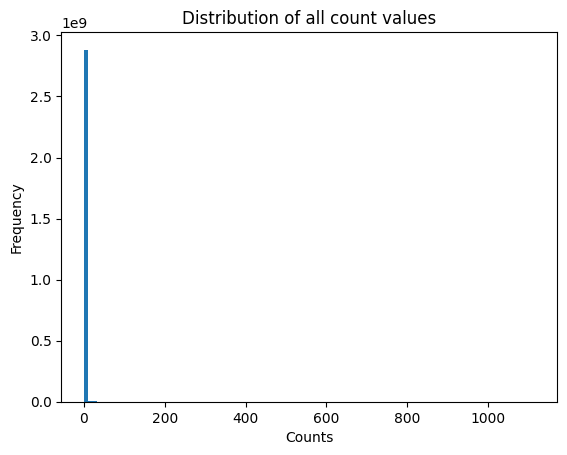

In [9]:
if sp.issparse(X):
    vals = X.toarray().ravel()
else:
    vals = np.asarray(X).ravel()

plt.hist(vals, bins=100)
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.title("Distribution of all count values")
plt.show()

Zero fraction: 0.801004415596955


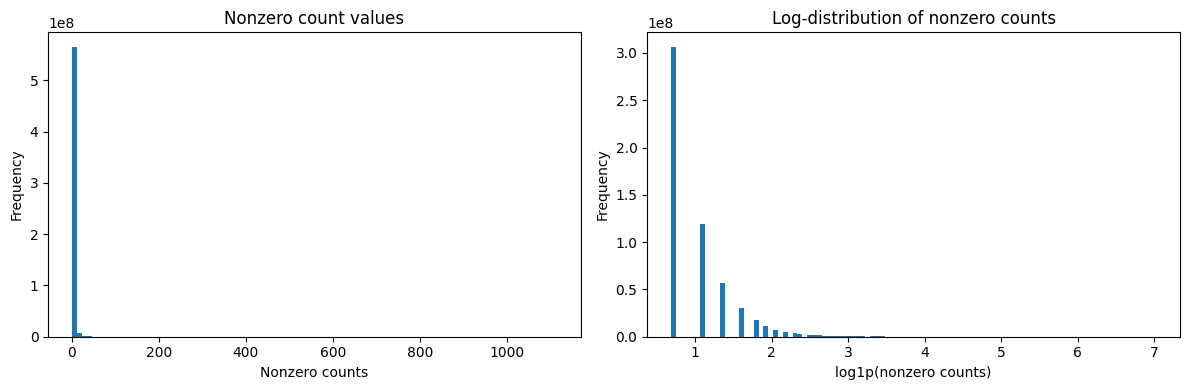

In [10]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

X = ad_all.X

if sp.issparse(X):
    vals_nz = X.data
    zero_fraction = 1 - X.nnz / (X.shape[0] * X.shape[1])
else:
    vals = np.asarray(X).ravel()
    vals_nz = vals[vals > 0]
    zero_fraction = np.mean(vals == 0)

print("Zero fraction:", zero_fraction)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(vals_nz, bins=100)
plt.xlabel("Nonzero counts")
plt.ylabel("Frequency")
plt.title("Nonzero count values")

plt.subplot(1, 2, 2)
plt.hist(np.log1p(vals_nz), bins=100)
plt.xlabel("log1p(nonzero counts)")
plt.ylabel("Frequency")
plt.title("Log-distribution of nonzero counts")

plt.tight_layout()
plt.show()

In [11]:
X.shape

(101543, 28515)

In [12]:
X.mean(axis=0).shape

(1, 28515)

In [13]:
 X.sum(axis=0).shape

(1, 28515)

In [14]:
 X.sum(axis=0)

matrix([[  805,   281, 17926, ..., 17110, 59098, 99840]], dtype=uint64)

In [15]:
gene_sums = np.asarray(X.sum(axis=0)).ravel()

In [17]:
sc.pp.calculate_qc_metrics(ad_all, inplace=True)

<AxesSubplot:>

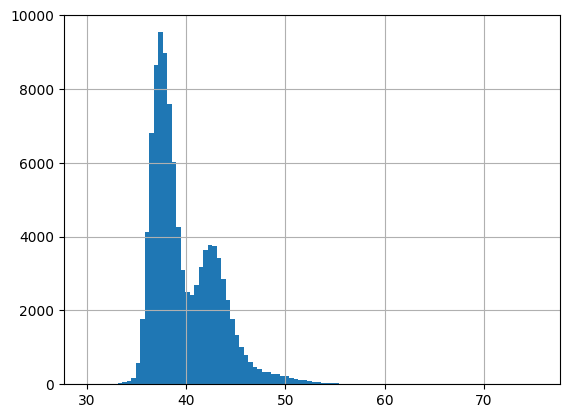

In [19]:
ad_all.obs.pct_counts_in_top_500_genes.hist(bins=100)

<AxesSubplot:>

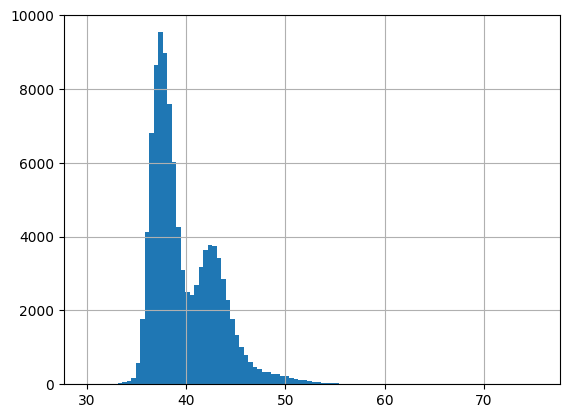

In [20]:
ad_all.obs.pct_counts_in_top_500_genes.hist(bins=100)

<AxesSubplot:>

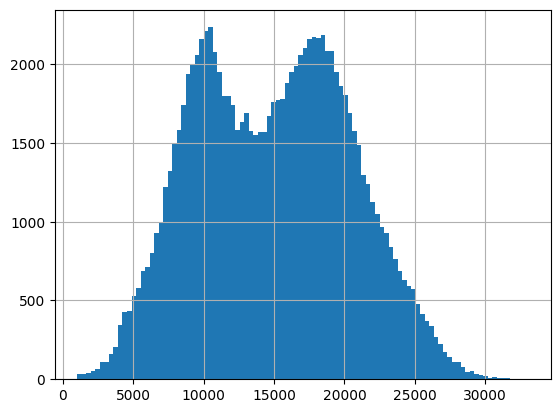

In [21]:
ad_all.obs.total_counts.hist(bins=100)

<AxesSubplot:>

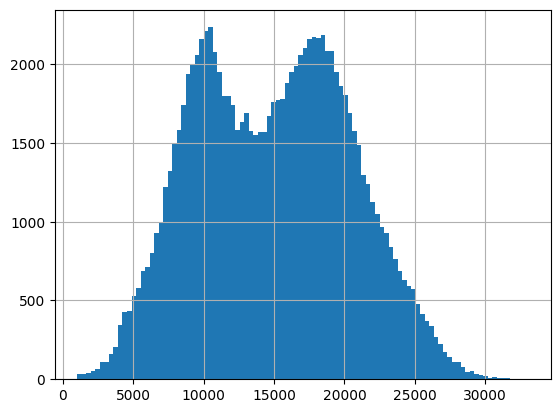

In [22]:
tc = ad_all.obs.total_counts
tc.hist(bins=100)

<AxesSubplot:>

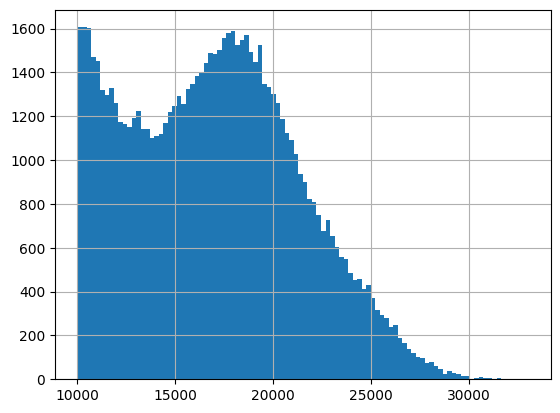

In [23]:
tc[tc>10000].hist(bins=100)

In [24]:
(tc<12000).sum()

35303

In [25]:
sc.pp.filter_cells(ad_all, min_counts=100)
sc.pp.filter_genes(ad_all, min_cells=1)

In [26]:
ad_all.layers = {"counts":ad_all.X.copy()} 

In [27]:
sc.pp.normalize_total(ad_all, inplace=True, layers=None, key_added="sizefactor")
sc.pp.log1p(ad_all)

<AxesSubplot:>

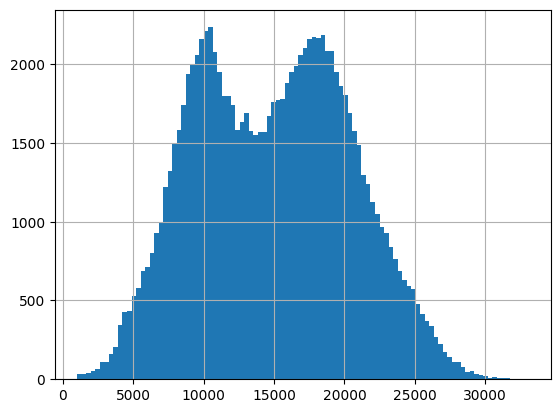

In [28]:
tc = ad_all.obs.total_counts
tc.hist(bins=100)

In [29]:
ad_all.var

,real_gene_name,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells
A1BG,A1BG,755,0.007928,0.007896,99.256473,805,6.692084,755
A1CF,A1CF,273,0.002767,0.002763,99.731148,281,5.641907,273
A2M,A2M,15020,0.176536,0.162575,85.208237,17926,9.794063,15020
A2ML1,A2ML1,6270,0.066927,0.064783,93.825276,6796,8.824237,6270
A3GALT2,A3GALT2,2079,0.021715,0.021483,97.952592,2205,7.698936,2079
...,...,...,...,...,...,...,...,...
ZYG11A,ZYG11A,3048,0.031701,0.031209,96.998316,3219,8.077137,3048
ZYG11B,ZYG11B,87308,2.705209,1.309740,14.018692,274695,12.523420,87308
ZYX,ZYX,15175,0.168500,0.155721,85.055592,17110,9.747477,15175
ZZEF1,ZZEF1,41098,0.582000,0.458690,59.526506,59098,10.986969,41098


In [30]:
import numpy as np
import scipy.sparse as sp

def compute_poisson_deviance(adata, layer=None, size_factors=None, chunk_size=1024):
    """
    Compute gene-wise Poisson deviance and store in adata.var['deviance_poisson'].

    Parameters
    ----------
    adata : AnnData
        AnnData object with counts in adata.X or in adata.layers[layer].
    layer : str or None
        Which layer to use. If None, uses adata.X.
        For NSF-style preprocessing, this should usually be raw counts.
    size_factors : array-like or None
        Optional per-observation size factors / library sizes.
        If None, uses row sums of the count matrix.
    chunk_size : int
        Number of genes to process at once for dense conversion when matrix is sparse.

    Returns
    -------
    dev : np.ndarray
        Array of shape (n_genes,) with Poisson deviances.
    """
    X = adata.layers[layer] if layer is not None else adata.X

    # Use raw counts as float
    if sp.issparse(X):
        X = X.tocsr()
    else:
        X = np.asarray(X, dtype=np.float64)

    n_obs, n_vars = adata.shape

    # Library sizes / exposure
    if size_factors is None:
        if sp.issparse(X):
            sf = np.asarray(X.sum(axis=1)).ravel().astype(np.float64)
        else:
            sf = X.sum(axis=1).astype(np.float64)
    else:
        sf = np.asarray(size_factors, dtype=np.float64).ravel()

    # Avoid division-by-zero observations
    valid_obs = sf > 0
    if not np.all(valid_obs):
        print(f"Filtering out {(~valid_obs).sum()} observations with zero total counts.")
        sf = sf[valid_obs]
        if sp.issparse(X):
            X = X[valid_obs]
        else:
            X = X[valid_obs, :]

    sf_sum = sf.sum()
    dev = np.zeros(n_vars, dtype=np.float64)

    # Process gene blocks
    for start in range(0, n_vars, chunk_size):
        end = min(start + chunk_size, n_vars)

        if sp.issparse(X):
            Y = X[:, start:end].toarray().astype(np.float64)   # shape: n_obs x block
        else:
            Y = X[:, start:end].astype(np.float64)

        # Gene totals
        gene_totals = Y.sum(axis=0)  # shape: block

        # Null model: mu_ij = sf_i * (sum_j y_ij / sum_i sf_i)
        # equivalently mu[:, g] = sf * gene_total[g] / sf_sum
        MU = np.outer(sf, gene_totals / sf_sum)

        # Compute term y * log(y/mu), with convention 0*log(0/mu)=0
        term = np.zeros_like(Y, dtype=np.float64)
        positive = Y > 0
        term[positive] = Y[positive] * np.log(Y[positive] / MU[positive])

        dev_block = 2.0 * np.sum(term - (Y - MU), axis=0)
        dev[start:end] = dev_block

    adata.var["deviance_poisson"] = dev
    return dev

In [31]:
ad_all.var

,real_gene_name,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells
A1BG,A1BG,755,0.007928,0.007896,99.256473,805,6.692084,755
A1CF,A1CF,273,0.002767,0.002763,99.731148,281,5.641907,273
A2M,A2M,15020,0.176536,0.162575,85.208237,17926,9.794063,15020
A2ML1,A2ML1,6270,0.066927,0.064783,93.825276,6796,8.824237,6270
A3GALT2,A3GALT2,2079,0.021715,0.021483,97.952592,2205,7.698936,2079
...,...,...,...,...,...,...,...,...
ZYG11A,ZYG11A,3048,0.031701,0.031209,96.998316,3219,8.077137,3048
ZYG11B,ZYG11B,87308,2.705209,1.309740,14.018692,274695,12.523420,87308
ZYX,ZYX,15175,0.168500,0.155721,85.055592,17110,9.747477,15175
ZZEF1,ZZEF1,41098,0.582000,0.458690,59.526506,59098,10.986969,41098


In [32]:
dev = compute_poisson_deviance(ad_all, layer=None)

<AxesSubplot:>

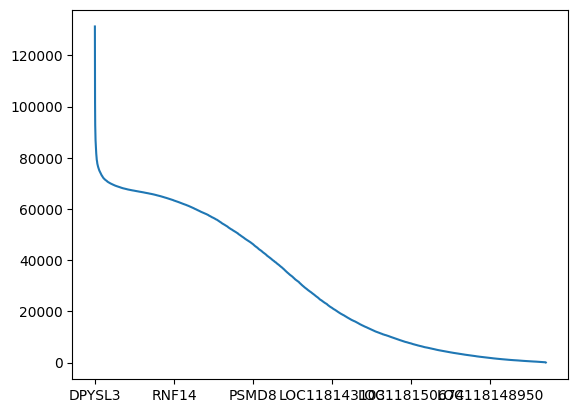

In [33]:
o = np.argsort(-ad_all.var['deviance_poisson'])
idx = list(range(ad_all.shape[0]))
random.shuffle(idx)
ad_all = ad_all[idx,o]
ad_all.var["deviance_poisson"].plot()

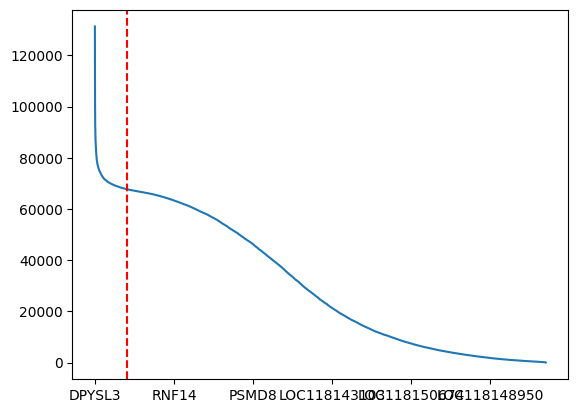

In [34]:
ad_all.var["deviance_poisson"].plot()
plt.axvline(2000, color="red", linestyle="--")

In [35]:
dev = ad_all.var["deviance_poisson"].values

print("min:", dev.min())
print("median:", np.median(dev))
print("q25:", np.quantile(dev, 0.25))
print("q75:", np.quantile(dev, 0.75))
print("max:", dev.max())

min: 72.78154143886852
median: 24577.21853748676
q25: 5362.472203408954
q75: 57754.5264001687
max: 131272.06062096194


In [36]:
ad_all = ad_all[:,:2000]
ad_all.write_h5ad("data/T_all_Visual_Sub-CTX_b100_filtered_J2000.h5ad",compression="gzip")

/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


In [37]:
ad2

NameError: name 'ad2' is not defined

In [38]:
ad_all.var.real_gene_name.to_csv("res/ad_all_2000_selected_genes.csv", index= False)

In [39]:
ad_all.var.real_gene_name

DPYSL3                DPYSL3
MBP                      MBP
MOBP                    MOBP
CALCA                  CALCA
PLP1                    PLP1
                    ...     
LOC100405247    LOC100405247
P3H3                    P3H3
PDE9A                  PDE9A
SCFD1                  SCFD1
SACM1L                SACM1L
Name: real_gene_name, Length: 2000, dtype: object

In [40]:
import pandas as pd

In [41]:
T1089_selected_genes = pd.read_csv("res/T1089-P0/T1089_P0_selected_genes.csv")

In [42]:
intersection = set(T1089_selected_genes["real_gene_name"].values) & set(ad_all.var.real_gene_name.values)

In [43]:
len(intersection)

1020